In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, mean_squared_error, r2_score
)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression

np.random.seed(42)


In [ ]:
df_raw = pd.read_csv("ashes_data.csv")
df = df_raw[df_raw["Winning_Team"] != "Not Played Yet"].copy().reset_index(drop=True)
upcoming = df_raw[df_raw["Winning_Team"] == "Not Played Yet"].copy()

print(f"Total records: {len(df_raw)}")
print(f"Completed matches: {len(df)}")
print(f"Upcoming 2025 fixtures: {len(upcoming)}")
print(f"Years covered: {df['Year'].min()} - {df['Year'].max()}")
df.head()


Total records: 70
Completed matches: 65
Upcoming 2025 fixtures: 5
Years covered: 2001 - 2023


,Year,Series,Match_Number,Venue,Home_Team,Away_Team,Toss_Winner,Toss_Decision,Result,Winning_Team,Player_of_Match,Home_Score,Away_Score,Home_Team_Form,Away_Team_Form,Venue_Type,Pitch_Condition,Weather
0,2001,Ashes,1,Edgbaston,England,Australia,Australia,Bat,Australia won by 118 runs,Australia,Shane Warne,294,279,Good,Excellent,Traditional,Seaming,Overcast
1,2001,Ashes,2,Lord's,England,Australia,England,Bat,Australia won by 8 wickets,Australia,Glenn McGrath,187,401,Good,Excellent,Traditional,Seaming,Sunny
2,2001,Ashes,3,Trent Bridge,England,Australia,Australia,Bat,Australia won by 7 wickets,Australia,Mark Waugh,190,447,Good,Excellent,Traditional,Seaming,Overcast
3,2001,Ashes,4,Headingley,England,Australia,England,Bat,Australia won by an innings and 25 runs,Australia,Adam Gilchrist,309,447,Good,Excellent,Traditional,Seaming,Sunny
4,2001,Ashes,5,The Oval,England,Australia,Australia,Bat,Australia won by an innings and 25 runs,Australia,Shane Warne,432,641,Good,Excellent,Traditional,Seaming,Sunny


## Data Preprocessing


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

df_processed = df.copy()
numeric_cols = ["Year", "Match_Number", "Home_Score", "Away_Score"]
categorical_cols = [
    "Venue", "Home_Team", "Away_Team", "Toss_Winner", "Toss_Decision",
    "Home_Team_Form", "Away_Team_Form", "Venue_Type", "Pitch_Condition", "Weather"
]

for col in numeric_cols:
    df_processed[col] = pd.to_numeric(df_processed[col], errors="coerce")
    if df_processed[col].isnull().any():
        df_processed[col] = df_processed[col].fillna(df_processed[col].median())

for col in categorical_cols:
    df_processed[col] = df_processed[col].astype(str).str.strip()
    if df_processed[col].isnull().any() or (df_processed[col] == "nan").any():
        df_processed[col] = df_processed[col].replace("nan", df_processed[col].mode()[0])
        df_processed[col] = df_processed[col].fillna(df_processed[col].mode()[0])

print("\nMissing values after imputation:")
print(df_processed.isnull().sum().sum())
print("\nWinning team distribution:")
print(df_processed["Winning_Team"].value_counts())


Missing values per column:
Year               0
Series             0
Match_Number       0
Venue              0
Home_Team          0
Away_Team          0
Toss_Winner        0
Toss_Decision      0
Result             0
Winning_Team       0
Player_of_Match    0
Home_Score         0
Away_Score         0
Home_Team_Form     0
Away_Team_Form     0
Venue_Type         0
Pitch_Condition    0
Weather            0
dtype: int64

Total missing: 0

Missing values after imputation:
0

Winning team distribution:
Winning_Team
Australia    36
England      17
Draw         12
Name: count, dtype: int64


In [ ]:
form_map = {"Poor": 1, "Average": 2, "Good": 3, "Excellent": 4}
df_processed["Home_Form_Score"] = df_processed["Home_Team_Form"].map(form_map)
df_processed["Away_Form_Score"] = df_processed["Away_Team_Form"].map(form_map)
df_processed["Form_Diff"] = df_processed["Home_Form_Score"] - df_processed["Away_Form_Score"]
df_processed["Score_Diff"] = df_processed["Home_Score"] - df_processed["Away_Score"]
df_processed["Total_Runs"] = df_processed["Home_Score"] + df_processed["Away_Score"]
df_processed["Home_Toss_Won"] = (df_processed["Toss_Winner"] == df_processed["Home_Team"]).astype(int)
df_processed["Home_Bat_First"] = (
    ((df_processed["Toss_Winner"] == df_processed["Home_Team"]) & (df_processed["Toss_Decision"] == "Bat"))
    | ((df_processed["Toss_Winner"] == df_processed["Away_Team"]) & (df_processed["Toss_Decision"] == "Bowl"))
).astype(int)
df_processed["England_Home"] = (df_processed["Home_Team"] == "England").astype(int)

def create_target(row):
    if row["Winning_Team"] == row["Home_Team"]:
        return "Home_Win"
    elif row["Winning_Team"] == row["Away_Team"]:
        return "Away_Win"
    return "Draw"

df_processed["Target"] = df_processed.apply(create_target, axis=1)

pre_match_features = [
    "Year", "Match_Number", "Home_Form_Score", "Away_Form_Score", "Form_Diff",
    "Home_Toss_Won", "Home_Bat_First", "England_Home",
    "Venue", "Home_Team", "Away_Team", "Toss_Winner", "Toss_Decision",
    "Home_Team_Form", "Away_Team_Form", "Venue_Type", "Pitch_Condition", "Weather"
]

X = df_processed[pre_match_features].copy()
y = df_processed["Target"].copy()

numeric_features = [
    "Year", "Match_Number", "Home_Form_Score", "Away_Form_Score",
    "Form_Diff", "Home_Toss_Won", "Home_Bat_First", "England_Home"
]
cat_features = [
    "Venue", "Home_Team", "Away_Team", "Toss_Winner", "Toss_Decision",
    "Home_Team_Form", "Away_Team_Form", "Venue_Type", "Pitch_Condition", "Weather"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), cat_features),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
print(f"Processed feature count: {X_train_processed.shape[1]}")
print("\nTarget distribution:")
print(y.value_counts())


Training samples: 52, Test samples: 13
Processed feature count: 39

Target distribution:
Target
Home_Win    37
Away_Win    16
Draw        12
Name: count, dtype: int64


## Exploratory Data Analysis


In [ ]:
print("Summary Statistics” Completed Ashes Matches (2001â€“2023)")
display(df_processed[["Year", "Match_Number", "Home_Score", "Away_Score", "Score_Diff", "Total_Runs"]].describe())

print("\nUpcoming 2025 Ashes Fixtures (excluded from modeling):")
display(upcoming[["Year", "Match_Number", "Venue", "Home_Team", "Away_Team", "Result"]])

print("\nSummary Statistics” Categorical Columns")
for col in categorical_cols + ["Winning_Team", "Target"]:
    print(f"\n{col}:")
    print(df_processed[col].value_counts())


Summary Statistics” Completed Ashes Matches (2001â€“2023)


,Year,Match_Number,Home_Score,Away_Score,Score_Diff,Total_Runs
count,65.000000,65.000000,65.000000,65.000000,65.000000,65.000000
mean,2011.846154,3.000000,374.969231,298.630769,76.338462,673.600000
std,6.878932,1.425219,135.311905,144.637431,205.875287,189.931468
min,2001.000000,1.000000,67.000000,60.000000,-415.000000,246.000000
25%,2006.000000,2.000000,281.000000,185.000000,-51.000000,547.000000
50%,2013.000000,3.000000,391.000000,279.000000,122.000000,641.000000
75%,2017.000000,4.000000,473.000000,384.000000,233.000000,759.000000
max,2023.000000,5.000000,662.000000,674.000000,445.000000,1109.000000



Upcoming 2025 Ashes Fixtures (excluded from modeling):


,Year,Match_Number,Venue,Home_Team,Away_Team,Result
65,2025,1,Optus Stadium,Australia,England,Not Played Yet
66,2025,2,The Gabba,Australia,England,Not Played Yet
67,2025,3,Adelaide Oval,Australia,England,Not Played Yet
68,2025,4,Melbourne Cricket Ground,Australia,England,Not Played Yet
69,2025,5,Sydney Cricket Ground,Australia,England,Not Played Yet



Summary Statistics” Categorical Columns

Venue:
Venue
Lord's          7
The Oval        7
Edgbaston       6
Brisbane        6
Melbourne       6
Adelaide        6
Sydney          6
Perth           5
Trent Bridge    4
Headingley      4
Old Trafford    4
Cardiff         2
Riverside       1
Hobart          1
Name: count, dtype: int64

Home_Team:
Home_Team
England      35
Australia    30
Name: count, dtype: int64

Away_Team:
Away_Team
Australia    35
England      30
Name: count, dtype: int64

Toss_Winner:
Toss_Winner
Australia    37
England      28
Name: count, dtype: int64

Toss_Decision:
Toss_Decision
Bat    65
Name: count, dtype: int64

Home_Team_Form:
Home_Team_Form
Good         55
Excellent    10
Name: count, dtype: int64

Away_Team_Form:
Away_Team_Form
Good         50
Excellent    15
Name: count, dtype: int64

Venue_Type:
Venue_Type
Traditional    33
Modern         32
Name: count, dtype: int64

Pitch_Condition:
Pitch_Condition
Seaming    33
Hard       32
Name: count, dtype: int64

We

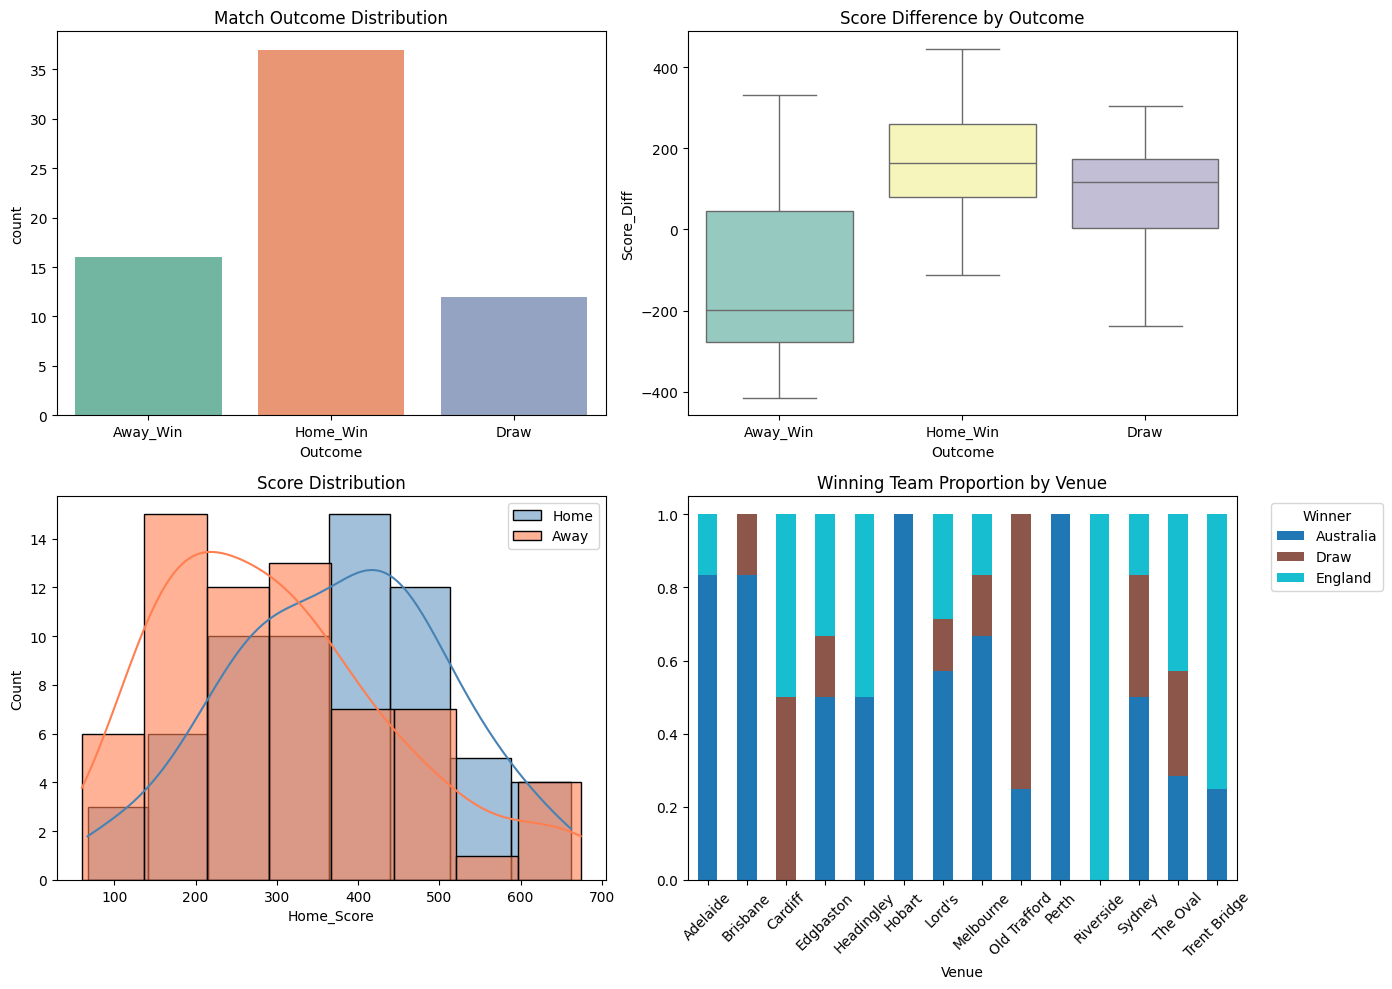

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(data=df_processed, x="Target", ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Match Outcome Distribution")
axes[0, 0].set_xlabel("Outcome")

sns.boxplot(data=df_processed, x="Target", y="Score_Diff", ax=axes[0, 1], palette="Set3")
axes[0, 1].set_title("Score Difference by Outcome")
axes[0, 1].set_xlabel("Outcome")

sns.histplot(df_processed["Home_Score"], kde=True, ax=axes[1, 0], color="steelblue", label="Home")
sns.histplot(df_processed["Away_Score"], kde=True, ax=axes[1, 0], color="coral", alpha=0.6, label="Away")
axes[1, 0].set_title("Score Distribution")
axes[1, 0].legend()

win_by_venue = df_processed.groupby("Venue")["Winning_Team"].value_counts(normalize=True).unstack(fill_value=0)
win_by_venue.plot(kind="bar", stacked=True, ax=axes[1, 1], colormap="tab10")
axes[1, 1].set_title("Winning Team Proportion by Venue")
axes[1, 1].set_xlabel("Venue")
axes[1, 1].tick_params(axis="x", rotation=45)
axes[1, 1].legend(title="Winner", bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()


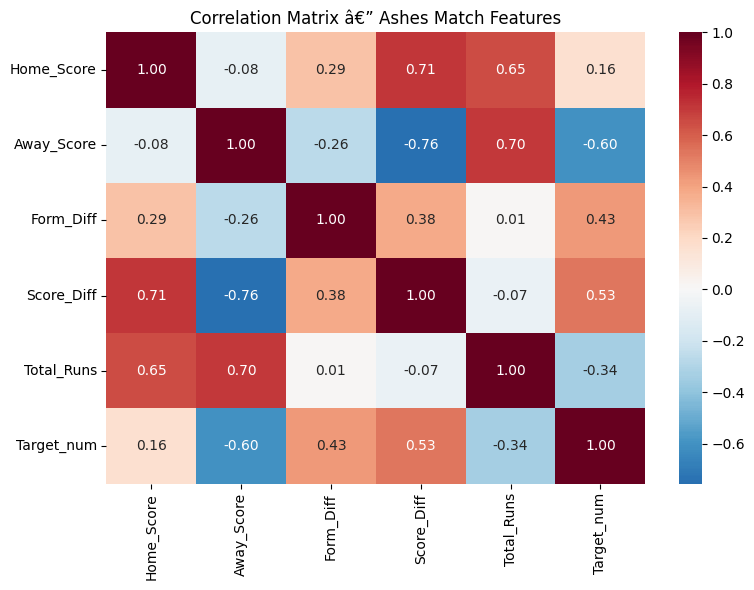

<Figure size 1200x500 with 0 Axes>

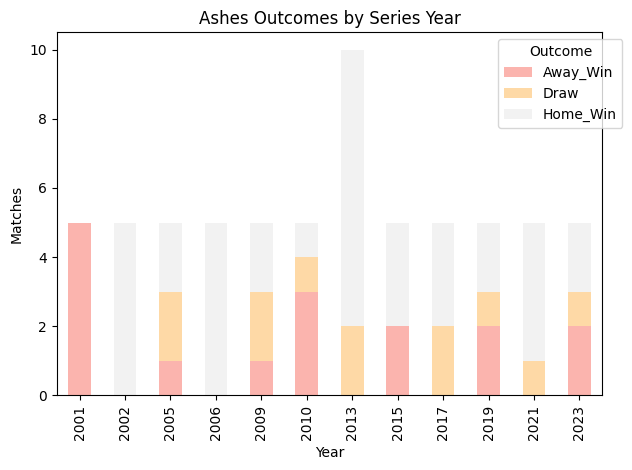

Australia wins: 36 | England wins: 17 | Draws: 12


In [ ]:
eda_numeric = df_processed[["Home_Score", "Away_Score", "Form_Diff", "Score_Diff", "Total_Runs"]].copy()
eda_numeric["Target_num"] = LabelEncoder().fit_transform(df_processed["Target"])
corr = eda_numeric.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="RdBu_r", center=0, fmt=".2f")
plt.title("Correlation Matrix â€” Ashes Match Features")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
yearly = df_processed.groupby("Year")["Target"].value_counts().unstack(fill_value=0)
yearly.plot(kind="bar", stacked=True, colormap="Pastel1")
plt.title("Ashes Outcomes by Series Year")
plt.xlabel("Year")
plt.ylabel("Matches")
plt.legend(title="Outcome", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

aus_wins = (df_processed["Winning_Team"] == "Australia").sum()
eng_wins = (df_processed["Winning_Team"] == "England").sum()
draws = (df_processed["Winning_Team"] == "Draw").sum()
print(f"Australia wins: {aus_wins} | England wins: {eng_wins} | Draws: {draws}")


## Model Implementation & Hyperparameter Tuning


In [ ]:
models_config = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=2000, random_state=42),
        "params": {"clf__C": [0.01, 0.1, 1, 10], "clf__solver": ["lbfgs", "liblinear"]},
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42, class_weight="balanced"),
        "params": {
            "clf__n_estimators": [50, 100, 200],
            "clf__max_depth": [5, 10, None],
            "clf__min_samples_split": [2, 5],
        },
    },
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "clf__n_estimators": [50, 100],
            "clf__learning_rate": [0.05, 0.1, 0.2],
            "clf__max_depth": [3, 5],
        },
    },
    "SVM": {
        "model": SVC(random_state=42, class_weight="balanced", probability=True),
        "params": {"clf__C": [0.1, 1, 10], "clf__kernel": ["rbf", "linear"], "clf__gamma": ["scale", "auto"]},
    },
    "K-Nearest Neighbors": {
        "model": KNeighborsClassifier(),
        "params": {"clf__n_neighbors": [3, 5, 7, 11], "clf__weights": ["uniform", "distance"]},
    },
}

results = []
best_models = {}
predictions_store = {}

for name, cfg in models_config.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("clf", cfg["model"]),
    ])
    grid = GridSearchCV(pipe, cfg["params"], cv=5, scoring="f1_weighted", n_jobs=-1)
    grid.fit(X_train, y_train)
    best = grid.best_estimator_
    best_models[name] = best
    y_pred = best.predict(X_test)
    predictions_store[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)
    cv_mean = cross_val_score(best, X_train, y_train, cv=5, scoring="f1_weighted").mean()

    results.append({
        "Model": name,
        "Best Params": str(grid.best_params_),
        "CV F1 (weighted)": round(cv_mean, 4),
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
    })
    print(f"\n{name} â€” Best params: {grid.best_params_}")
    print(classification_report(y_test, y_pred, zero_division=0))

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False)
results_df



Logistic Regression â€” Best params: {'clf__C': 0.1, 'clf__solver': 'liblinear'}
              precision    recall  f1-score   support

    Away_Win       0.33      0.33      0.33         3
        Draw       0.00      0.00      0.00         2
    Home_Win       0.70      0.88      0.78         8

    accuracy                           0.62        13
   macro avg       0.34      0.40      0.37        13
weighted avg       0.51      0.62      0.56        13


Random Forest â€” Best params: {'clf__max_depth': 5, 'clf__min_samples_split': 2, 'clf__n_estimators': 50}
              precision    recall  f1-score   support

    Away_Win       0.33      0.33      0.33         3
        Draw       0.00      0.00      0.00         2
    Home_Win       0.70      0.88      0.78         8

    accuracy                           0.62        13
   macro avg       0.34      0.40      0.37        13
weighted avg       0.51      0.62      0.56        13


Gradient Boosting â€” Best params: {'clf__learn

,Model,Best Params,CV F1 (weighted),Accuracy,Precision,Recall,F1-Score
2,Gradient Boosting,"{'clf__learning_rate': 0.05, 'clf__max_depth':...",0.5519,0.6154,0.5556,0.6154,0.5837
0,Logistic Regression,"{'clf__C': 0.1, 'clf__solver': 'liblinear'}",0.5875,0.6154,0.5077,0.6154,0.5556
1,Random Forest,"{'clf__max_depth': 5, 'clf__min_samples_split'...",0.4674,0.6154,0.5077,0.6154,0.5556
4,K-Nearest Neighbors,"{'clf__n_neighbors': 7, 'clf__weights': 'unifo...",0.5791,0.6154,0.5077,0.6154,0.5556
3,SVM,"{'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker...",0.5318,0.5385,0.4679,0.5385,0.5003


## Regression Models (RMSE on Total Runs)


In [ ]:
X_reg = df_processed[pre_match_features].copy()
y_reg = df_processed["Total_Runs"].copy()
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

reg_models = {
    "Linear Regression": (LinearRegression(), {}),
    "Random Forest Regressor": (
        RandomForestRegressor(random_state=42),
        {"reg__n_estimators": [50, 100], "reg__max_depth": [5, 10, None]},
    ),
    "Gradient Boosting Regressor": (
        GradientBoostingRegressor(random_state=42),
        {"reg__n_estimators": [50, 100], "reg__learning_rate": [0.05, 0.1], "reg__max_depth": [3, 5]},
    ),
}

reg_results = []
for name, (model, params) in reg_models.items():
    pipe = Pipeline([
        ("preprocessor", ColumnTransformer(
            transformers=[
                ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_features),
                ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))]), cat_features),
            ]
        )),
        ("reg", model),
    ])
    if params:
        grid = GridSearchCV(pipe, params, cv=5, scoring="neg_root_mean_squared_error", n_jobs=-1)
        grid.fit(X_reg_train, y_reg_train)
        best_reg = grid.best_estimator_
        best_params = grid.best_params_
    else:
        pipe.fit(X_reg_train, y_reg_train)
        best_reg = pipe
        best_params = {}
    y_reg_pred = best_reg.predict(X_reg_test)
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
    r2 = r2_score(y_reg_test, y_reg_pred)
    reg_results.append({
        "Model": name,
        "Best Params": str(best_params),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4),
    })

reg_results_df = pd.DataFrame(reg_results).sort_values("RMSE")
print("Regression Results” Predicting Total Runs")
reg_results_df


Regression Results” Predicting Total Runs


,Model,Best Params,RMSE,R2
1,Random Forest Regressor,"{'reg__max_depth': 5, 'reg__n_estimators': 50}",170.0421,-0.2031
2,Gradient Boosting Regressor,"{'reg__learning_rate': 0.05, 'reg__max_depth':...",184.7287,-0.4199
0,Linear Regression,{},205.3444,-0.7545


## Comparative Analysis


Classification Model Comparison


,Model,Best Params,CV F1 (weighted),Accuracy,Precision,Recall,F1-Score
2,Gradient Boosting,"{'clf__learning_rate': 0.05, 'clf__max_depth':...",0.5519,0.6154,0.5556,0.6154,0.5837
0,Logistic Regression,"{'clf__C': 0.1, 'clf__solver': 'liblinear'}",0.5875,0.6154,0.5077,0.6154,0.5556
1,Random Forest,"{'clf__max_depth': 5, 'clf__min_samples_split'...",0.4674,0.6154,0.5077,0.6154,0.5556
4,K-Nearest Neighbors,"{'clf__n_neighbors': 7, 'clf__weights': 'unifo...",0.5791,0.6154,0.5077,0.6154,0.5556
3,SVM,"{'clf__C': 1, 'clf__gamma': 'scale', 'clf__ker...",0.5318,0.5385,0.4679,0.5385,0.5003


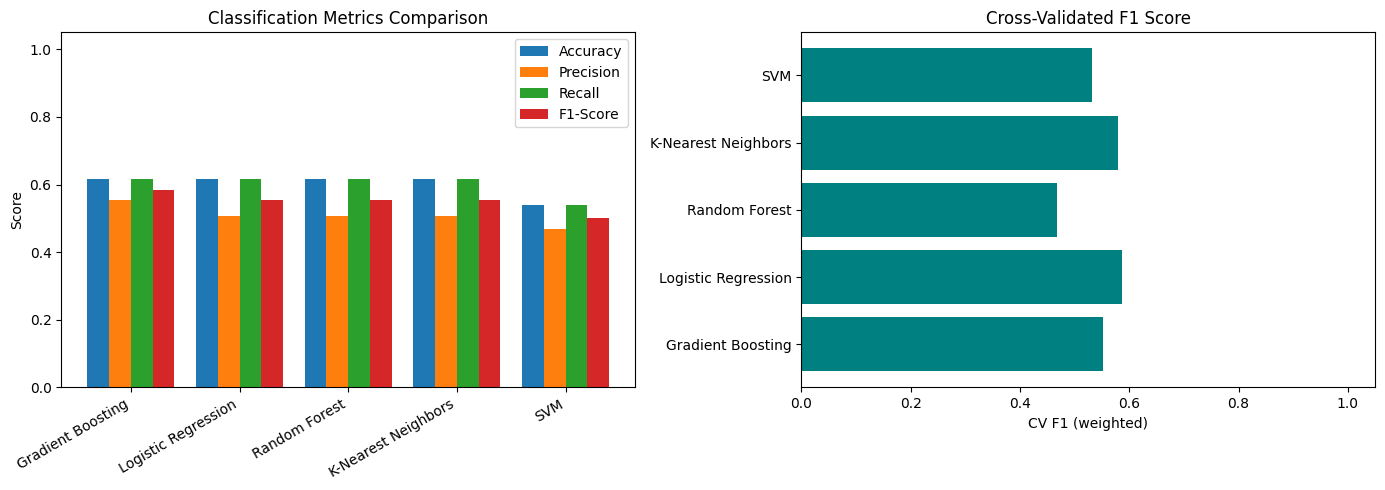

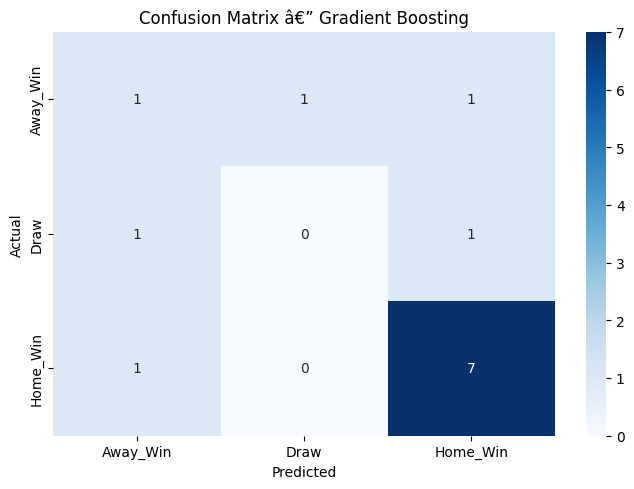


Best Classification Model: Gradient Boosting
Best Regression Model (lowest RMSE): Random Forest Regressor


,Model,Accuracy,Precision,Recall,F1-Score,CV F1 (weighted),RMSE,R2
0,Gradient Boosting,0.6154,0.5556,0.6154,0.5837,0.5519,NaN,NaN
1,Gradient Boosting Regressor,NaN,NaN,NaN,NaN,NaN,184.7287,-0.4199
2,K-Nearest Neighbors,0.6154,0.5077,0.6154,0.5556,0.5791,NaN,NaN
3,Linear Regression,NaN,NaN,NaN,NaN,NaN,205.3444,-0.7545
4,Logistic Regression,0.6154,0.5077,0.6154,0.5556,0.5875,NaN,NaN
5,Random Forest,0.6154,0.5077,0.6154,0.5556,0.4674,NaN,NaN
6,Random Forest Regressor,NaN,NaN,NaN,NaN,NaN,170.0421,-0.2031
7,SVM,0.5385,0.4679,0.5385,0.5003,0.5318,NaN,NaN


In [ ]:
print("Classification Model Comparison")
display(results_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics = ["Accuracy", "Precision", "Recall", "F1-Score"]
x = np.arange(len(results_df))
width = 0.2
for i, metric in enumerate(metrics):
    axes[0].bar(x + i * width, results_df[metric], width, label=metric)
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(results_df["Model"], rotation=30, ha="right")
axes[0].set_ylabel("Score")
axes[0].set_title("Classification Metrics Comparison")
axes[0].set_ylim(0, 1.05)
axes[0].legend()

axes[1].barh(results_df["Model"], results_df["CV F1 (weighted)"], color="teal")
axes[1].set_xlabel("CV F1 (weighted)")
axes[1].set_title("Cross-Validated F1 Score")
axes[1].set_xlim(0, 1.05)

plt.tight_layout()
plt.show()

best_clf_name = results_df.iloc[0]["Model"]
best_clf = best_models[best_clf_name]
y_best_pred = predictions_store[best_clf_name]

cm = confusion_matrix(y_test, y_best_pred, labels=sorted(y.unique()))
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix â€” {best_clf_name}")
plt.tight_layout()
plt.show()

print(f"\nBest Classification Model: {best_clf_name}")
print(f"Best Regression Model (lowest RMSE): {reg_results_df.iloc[0]['Model']}")

comparison = results_df[["Model", "Accuracy", "Precision", "Recall", "F1-Score", "CV F1 (weighted)"]].merge(
    reg_results_df[["Model", "RMSE", "R2"]], on="Model", how="outer"
)
comparison
